# Ahrefs SEO Analysis
## Keyword Difficulty, Search Volume & Competitive Positioning

This notebook analyzes Ahrefs organic keyword, position, and page-level data 
for a Nepal-based IT and cloud consulting firm.

**Dataset:** Organic keywords · Organic positions · Top pages  
**Objective:** Evaluate keyword difficulty vs current rankings, identify 
low-competition opportunities, and validate intent classifications from Google.

## Data Loading
Loading three Ahrefs exports: organic keywords, organic positions, and top pages.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
keywords = pd.read_csv('../../data/ahrefs_organic_keywords.csv')
positions = pd.read_csv('../../data/ahrefs_organic_positions.csv')
pages = pd.read_csv('../../data/ahrefs_top_pages.csv')

print("Keywords:", keywords.shape)
print("Positions:", positions.shape)
print("Pages:", pages.shape)

Keywords: (57, 21)
Positions: (60, 19)
Pages: (8, 11)


## Data Cleaning 
Stripping quote characters from column names and values, converting numeric 
columns to correct types, and masking client URLs. Also, fixing the column type handling for Pandas 4 compatibility.

In [3]:
def clean_ahrefs(df):
    # Strip quotes from column names
    df.columns = df.columns.str.replace('"', '', regex=False).str.strip()
    
    # Strip quotes from string values — Pandas 4 compatible
    for col in df.select_dtypes(include='str').columns:
        df[col] = df[col].str.replace('"', '', regex=False).str.strip()
        df[col] = df[col].str.replace(r'https?://[^/]+', '[client-site]', regex=True)
    
    return df

keywords = clean_ahrefs(keywords)
positions = clean_ahrefs(positions)
pages = clean_ahrefs(pages)

print("Cleaned successfully.")
print("Keywords columns:", keywords.columns.tolist())
print("Positions columns:", positions.columns.tolist())
print("Pages columns:", pages.columns.tolist())

Cleaned successfully.
Keywords columns: ['Keyword', 'Country', 'Location', 'Language', 'Entities', 'Branded', 'Local', 'Navigational', 'Informational', 'Commercial', 'Transactional', 'SERP features', 'Volume', 'KD', 'CPC', 'Organic traffic', 'Paid traffic', 'Current position', 'Current position kind', 'Current URL', 'Updated']
Positions columns: ['Keyword', 'Country', 'Language', 'Entities', 'Branded', 'Local', 'Navigational', 'Informational', 'Commercial', 'Transactional', 'SERP features', 'Volume', 'KD', 'CPC', 'Organic traffic', 'Position', 'Position kind', 'URL', 'Updated']
Pages columns: ['URL', 'UR', 'Traffic', 'Traffic value', 'Referring domains', 'Keywords', 'Top keyword', 'Top keyword: Country', 'Top keyword: Volume', 'Top keyword: Position', 'Page type']


## Type Conversion
Converting numeric columns from string to integer/float for analysis.

In [4]:
numeric_cols_keywords = ['Volume', 'KD', 'CPC', 'Organic traffic', 'Paid traffic', 'Current position']
numeric_cols_positions = ['Volume', 'KD', 'CPC', 'Organic traffic', 'Position']
numeric_cols_pages = ['UR', 'Traffic', 'Traffic value', 'Referring domains', 'Keywords', 'Top keyword: Volume', 'Top keyword: Position']

for col in numeric_cols_keywords:
    keywords[col] = pd.to_numeric(keywords[col], errors='coerce')

for col in numeric_cols_positions:
    positions[col] = pd.to_numeric(positions[col], errors='coerce')

for col in numeric_cols_pages:
    pages[col] = pd.to_numeric(pages[col], errors='coerce')

print("Keywords dtypes:\n", keywords[numeric_cols_keywords].dtypes)
print("\nPositions dtypes:\n", positions[numeric_cols_positions].dtypes)
print("\nPages dtypes:\n", pages[numeric_cols_pages].dtypes)

Keywords dtypes:
 Volume                int64
KD                    int64
CPC                 float64
Organic traffic       int64
Paid traffic          int64
Current position      int64
dtype: object

Positions dtypes:
 Volume               int64
KD                   int64
CPC                float64
Organic traffic      int64
Position             int64
dtype: object

Pages dtypes:
 UR                       float64
Traffic                    int64
Traffic value            float64
Referring domains          int64
Keywords                   int64
Top keyword: Volume        int64
Top keyword: Position      int64
dtype: object


## Exploratory Analysis
### Keyword difficulty distribution
Understanding the spread of KD scores across all tracked keywords.

In [5]:
print("Keyword difficulty summary:")
print(keywords['KD'].describe())

print("\nVolume summary:")
print(keywords['Volume'].describe())

print("\nCurrent position summary:")
print(keywords['Current position'].describe())

print("\nIntent distribution:")
intent_cols = ['Branded', 'Local', 'Navigational', 'Informational', 'Commercial', 'Transactional']
for col in intent_cols:
    true_count = (keywords[col] == 'true').sum()
    print(f"  {col}: {true_count}")

Keyword difficulty summary:
count    57.000000
mean      7.508772
std      15.606916
min       0.000000
25%       0.000000
50%       2.000000
75%       8.000000
max      84.000000
Name: KD, dtype: float64

Volume summary:
count       57.000000
mean       640.877193
std       1825.165629
min          0.000000
25%         10.000000
50%         40.000000
75%        150.000000
max      11000.000000
Name: Volume, dtype: float64

Current position summary:
count    57.000000
mean     11.105263
std       8.825054
min       1.000000
25%       7.000000
50%       9.000000
75%      11.000000
max      48.000000
Name: Current position, dtype: float64

Intent distribution:
  Branded: 50
  Local: 8
  Navigational: 0
  Informational: 57
  Commercial: 1
  Transactional: 0


### High opportunity keywords
Identifying keywords with high search volume and low keyword difficulty, which is the sweet spot for content optimization.

In [6]:
keywords['opportunity_flag'] = (
    (keywords['Volume'] > keywords['Volume'].median()) &
    (keywords['KD'] < 20)
)

opportunity_keywords = keywords[keywords['opportunity_flag']].sort_values(
    'Volume', ascending=False
)[['Keyword', 'Volume', 'KD', 'Current position', 'Organic traffic', 'Current URL']]

print(f"High opportunity keywords: {len(opportunity_keywords)}")
print(opportunity_keywords.to_string())

High opportunity keywords: 24
                               Keyword  Volume  KD  Current position  Organic traffic                                                 Current URL
4               zoom audio not working    6500   0                21               11  [client-site]/blogs/fix-zoom-audio-mic-speaker-issue-fast/
5              zoom camera not working    4000   1                21                9     [client-site]/blogs/zoom-camera-issues-easy-detect-fix/
52              zoom video not working    2700   4                26                0     [client-site]/blogs/zoom-camera-issues-easy-detect-fix/
13          camera not working on zoom     900   1                19                4     [client-site]/blogs/zoom-camera-issues-easy-detect-fix/
2                     zoom not working     800   9                13               13    [client-site]/blogs/zoom-not-working-troubleshoot-guide/
54                       aws databases     700  17                45                0         

### Keyword difficulty vs search volume
Scatter plot identifying high-volume, low-competition keyword opportunities.

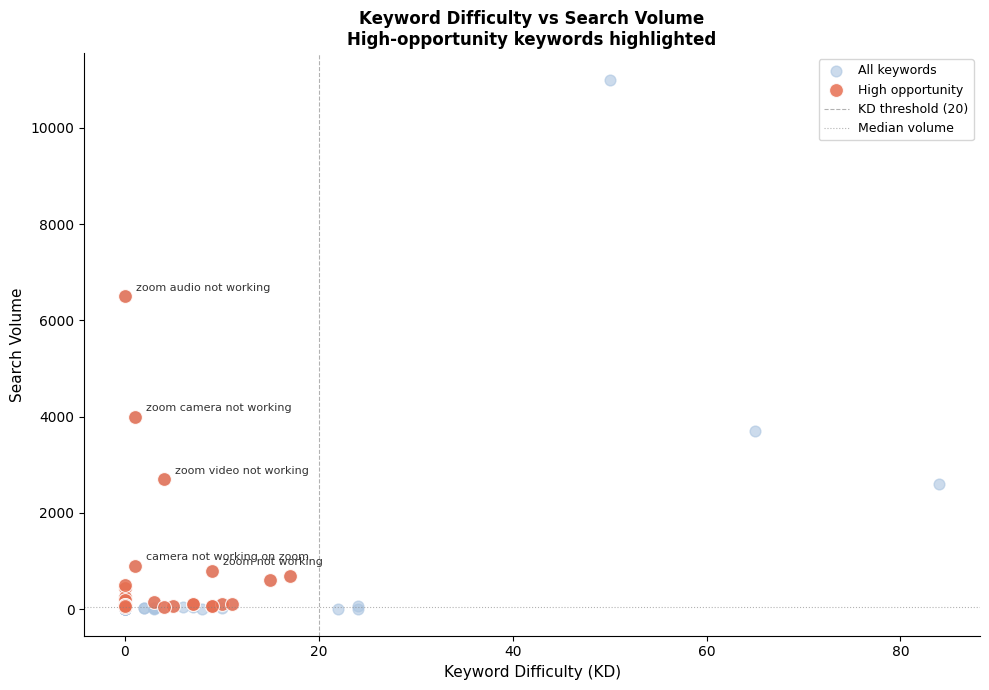

Chart saved.


In [7]:
os.makedirs('../output-ahrefs/chart', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 7))

# All keywords
ax.scatter(
    keywords['KD'],
    keywords['Volume'],
    color='#aac4e0',
    s=60,
    alpha=0.6,
    label='All keywords'
)

# Opportunity keywords
opp = keywords[keywords['opportunity_flag']]
ax.scatter(
    opp['KD'],
    opp['Volume'],
    color='#E76F51',
    s=100,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.8,
    label='High opportunity'
)

# Label top 5 by volume
top5 = opp.nlargest(5, 'Volume')
for _, row in top5.iterrows():
    ax.annotate(
        row['Keyword'],
        (row['KD'], row['Volume']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8,
        color='#333333'
    )

ax.axvline(x=20, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='KD threshold (20)')
ax.axhline(y=keywords['Volume'].median(), color='grey', linestyle=':', linewidth=0.8, alpha=0.6, label='Median volume')

ax.set_xlabel('Keyword Difficulty (KD)', fontsize=11)
ax.set_ylabel('Search Volume', fontsize=11)
ax.set_title('Keyword Difficulty vs Search Volume\nHigh-opportunity keywords highlighted', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-ahrefs/chart/kd_vs_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Intent Classification Comparison
Comparing Ahrefs built-in intent labels against our Phase 2 
rule-based classifier from the Google analysis.

In [8]:
# Ahrefs intent distribution
intent_cols = ['Informational', 'Commercial', 'Transactional', 'Navigational', 'Local', 'Branded']

ahrefs_intent = {}
for col in intent_cols:
    ahrefs_intent[col] = (keywords[col] == 'true').sum()

print("Ahrefs intent distribution:")
for intent, count in sorted(ahrefs_intent.items(), key=lambda x: x[1], reverse=True):
    print(f"  {intent}: {count}")

print("\nNote: Ahrefs allows multiple intent labels per keyword")
print(f"Total keywords: {len(keywords)}")
print(f"Total intent flags: {sum(ahrefs_intent.values())}")

Ahrefs intent distribution:
  Informational: 57
  Branded: 50
  Local: 8
  Commercial: 1
  Transactional: 0
  Navigational: 0

Note: Ahrefs allows multiple intent labels per keyword
Total keywords: 57
Total intent flags: 116


## Position vs Keyword Difficulty Analysis
Evaluating whether current rankings reflect keyword difficulty:
Are easy keywords being ranked well, or is there a mismatch?

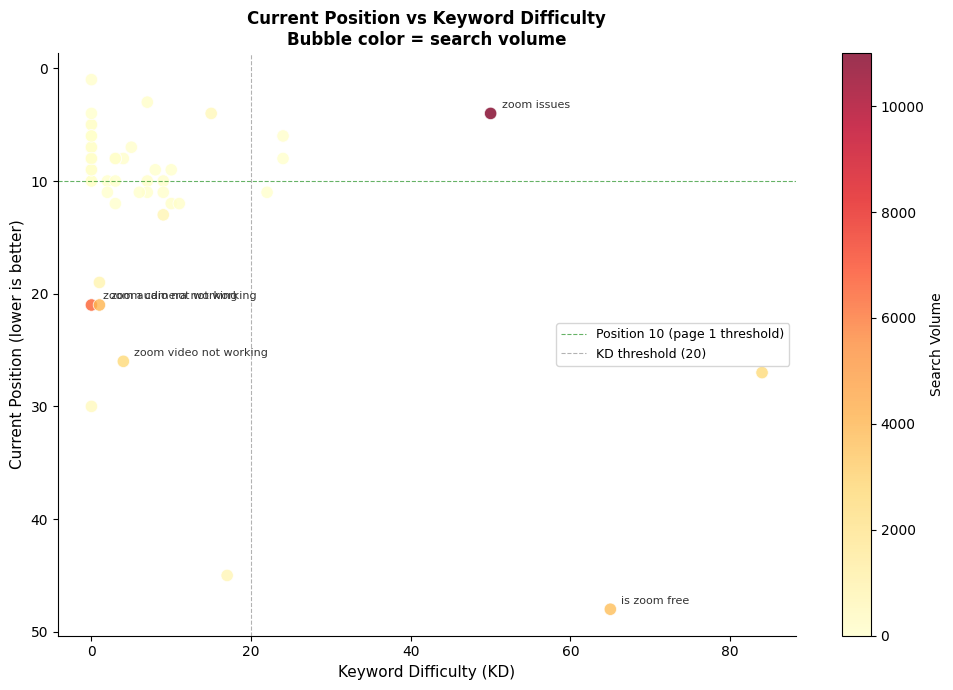

Chart saved.


In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    keywords['KD'],
    keywords['Current position'],
    c=keywords['Volume'],
    cmap='YlOrRd',
    s=80,
    alpha=0.8,
    edgecolors='white',
    linewidth=0.6
)

# Colorbar for volume
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Search Volume', fontsize=10)

# Label high volume keywords
top_volume = keywords.nlargest(5, 'Volume')
for _, row in top_volume.iterrows():
    ax.annotate(
        row['Keyword'],
        (row['KD'], row['Current position']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8,
        color='#333333'
    )

# Reference lines
ax.axhline(y=10, color='green', linestyle='--', linewidth=0.8, alpha=0.6, label='Position 10 (page 1 threshold)')
ax.axvline(x=20, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='KD threshold (20)')

ax.invert_yaxis()
ax.set_xlabel('Keyword Difficulty (KD)', fontsize=11)
ax.set_ylabel('Current Position (lower is better)', fontsize=11)
ax.set_title('Current Position vs Keyword Difficulty\nBubble color = search volume', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-ahrefs/chart/position_vs_kd.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Ahrefs Keyword Opportunity Scoring
Combining volume, keyword difficulty, and current position into 
a keyword-level opportunity score to prioritize optimization effort.

In [10]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# Higher volume = more opportunity
# Lower KD = more opportunity (invert)
# Higher position number = more room to improve (invert ranking)
keywords['volume_norm'] = normalize(keywords['Volume'])
keywords['kd_gap'] = 1 - normalize(keywords['KD'])
keywords['position_gap'] = normalize(keywords['Current position'])

keywords['ahrefs_opportunity'] = (
    keywords['volume_norm'] * 0.40 +
    keywords['kd_gap'] * 0.35 +
    keywords['position_gap'] * 0.25
)

top_kw = keywords.sort_values('ahrefs_opportunity', ascending=False)[
    ['Keyword', 'Volume', 'KD', 'Current position', 'ahrefs_opportunity']
].head(10)

print(top_kw.to_string())

                              Keyword  Volume  KD  Current position  ahrefs_opportunity
4              zoom audio not working    6500   0                21            0.692747
5             zoom camera not working    4000   1                21            0.597671
52             zoom video not working    2700   4                26            0.564494
0                         zoom issues   11000  50                 4            0.557624
54                      aws databases     700  17                45            0.538664
46        zoom microphone not working     500   0                30            0.522437
13         camera not working on zoom     900   1                19            0.474305
51                       is zoom free    3700  65                48            0.463712
1   zoom is unable to detect a camera     450   0                 9            0.408917
2                    zoom not working     800   9                13            0.405421


### Top keyword opportunities & their final ranking

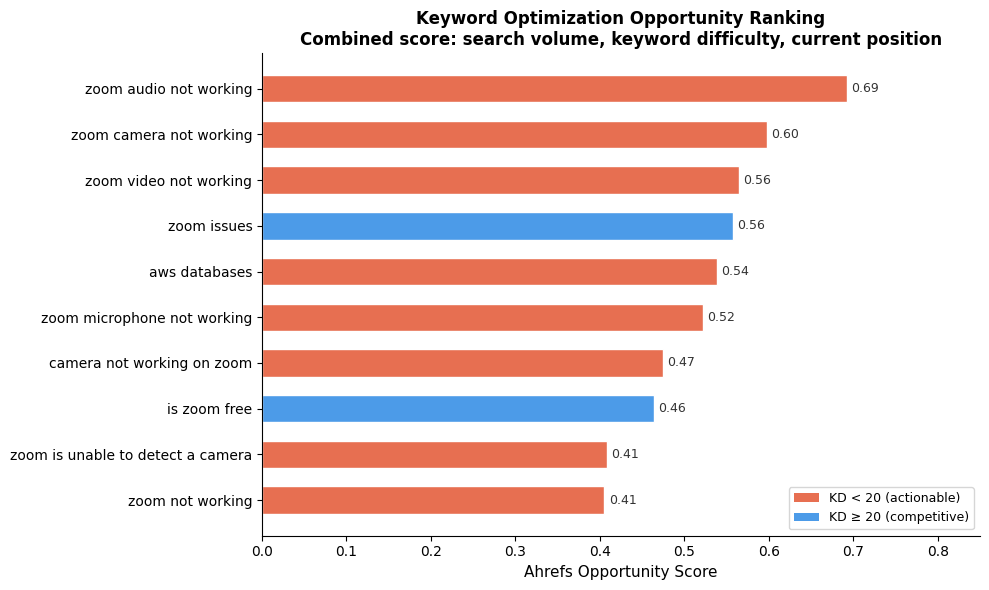

Chart saved.


In [11]:
top10 = keywords.sort_values('ahrefs_opportunity', ascending=False).head(10).copy()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E76F51' if kd < 20 else '#4C9BE8' for kd in top10['KD']]

bars = ax.barh(
    top10['Keyword'][::-1],
    top10['ahrefs_opportunity'][::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.6
)

for bar, score in zip(bars, top10['ahrefs_opportunity'][::-1]):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.2f}',
        va='center',
        fontsize=9,
        color='#333333'
    )

ax.set_xlabel('Ahrefs Opportunity Score', fontsize=11)
ax.set_title(
    'Keyword Optimization Opportunity Ranking\n'
    'Combined score: search volume, keyword difficulty, current position',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlim(0, 0.85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E76F51', label='KD < 20 (actionable)'),
    Patch(facecolor='#4C9BE8', label='KD ≥ 20 (competitive)')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../output-ahrefs/chart/keyword_opportunity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [12]:

print(pages.head(8).to_string())

                                                          URL   UR  Traffic  Traffic value  Referring domains  Keywords                        Top keyword Top keyword: Country  Top keyword: Volume  Top keyword: Position Page type
0    [client-site]/blogs/zoom-not-working-troubleshoot-guide/  5.0       91          30.15                  0        26                        zoom issues        United States                11000                     20          
1                        [client-site]/blogs/paypal-in-nepal/  4.5       39           0.36                  1         8       is paypal available in nepal                Nepal                  250                      8          
2     [client-site]/blogs/zoom-camera-issues-easy-detect-fix/  5.0       35           5.95                  0         9  zoom is unable to detect a camera        United States                  450                      9          
3  [client-site]/blogs/fix-zoom-audio-mic-speaker-issue-fast/  0.0       11     

## Page-level Analysis
Connecting Ahrefs page metrics, like URL Rating, traffic, and referring domains, 
and keyword count to identify page-level strengths and gaps.

In [13]:
# Clean URL to relative path for potential joining with GA4 later
pages['Page'] = pages['URL'].str.replace(r'[client-site]', '', regex=False).str.rstrip('/')

print(pages[['Page', 'URL', 'Traffic', 'Referring domains', 'Keywords', 'Top keyword', 'Top keyword: Volume', 'Top keyword: Position']].to_string())

                                           Page                                                         URL  Traffic  Referring domains  Keywords                        Top keyword  Top keyword: Volume  Top keyword: Position
0    /blogs/zoom-not-working-troubleshoot-guide    [client-site]/blogs/zoom-not-working-troubleshoot-guide/       91                  0        26                        zoom issues                11000                     20
1                        /blogs/paypal-in-nepal                        [client-site]/blogs/paypal-in-nepal/       39                  1         8       is paypal available in nepal                  250                      8
2     /blogs/zoom-camera-issues-easy-detect-fix     [client-site]/blogs/zoom-camera-issues-easy-detect-fix/       35                  0         9  zoom is unable to detect a camera                  450                      9
3  /blogs/fix-zoom-audio-mic-speaker-issue-fast  [client-site]/blogs/fix-zoom-audio-mic-speaker-issu

### Ahrefs vs GA4: A Traffic Comparison
Joining Ahrefs page traffic with GA4 sessions to check whether both tools agree on page performance.

In [14]:
# Load GA4 data for comparison
ga4_compare = pd.read_csv('../../data/ga4_landing_page.csv', skiprows=9)
ga4_compare.columns = ga4_compare.columns.str.strip()
ga4_compare = ga4_compare.rename(columns={'Landing page': 'Page'})
ga4_compare['Page'] = ga4_compare['Page'].str.rstrip('/')

# Merge Ahrefs pages with GA4
combined = pages.merge(
    ga4_compare[['Page', 'Sessions', 'Average engagement time per session']],
    on='Page',
    how='left'
)

print(combined[['Page', 'Traffic', 'Sessions', 'Referring domains', 'Keywords']].to_string())

                                           Page  Traffic  Sessions  Referring domains  Keywords
0    /blogs/zoom-not-working-troubleshoot-guide       91       140                  0        26
1                        /blogs/paypal-in-nepal       39       257                  1         8
2     /blogs/zoom-camera-issues-easy-detect-fix       35        42                  0         9
3  /blogs/fix-zoom-audio-mic-speaker-issue-fast       11         7                  0         2
4  /blogs/what-is-aws-guide-amazon-web-services        1        74                  1         1
5   /blogs/simple-comparison-of-zoom-vs-discord        1       338                  0         2
6         /blogs/complete-guide-to-aws-database        0        78                  0         2
7      /blogs/free-zoom-vs-paid-which-is-better        0        52                  0         2


### Ahrefs vs GA4 traffic gap
Visualizing the difference between Ahrefs organic traffic and GA4 total sessions to identify non-organic traffic dependence.

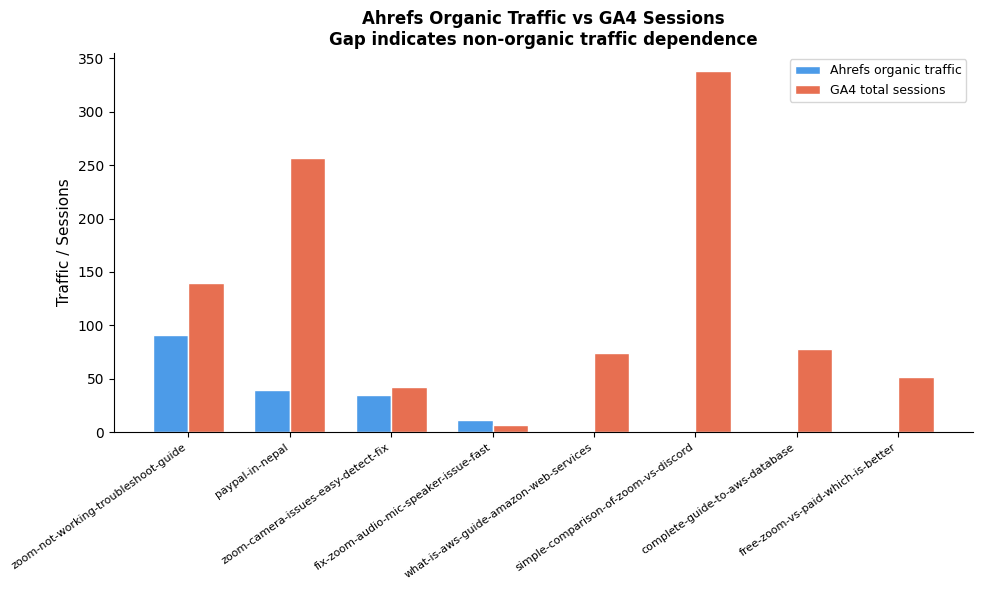

Chart saved.


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(combined))
width = 0.35

labels = combined['Page'].str.replace('/blogs/', '', regex=False)

bars1 = ax.bar(
    [i - width/2 for i in x],
    combined['Traffic'],
    width,
    label='Ahrefs organic traffic',
    color='#4C9BE8',
    edgecolor='white'
)

bars2 = ax.bar(
    [i + width/2 for i in x],
    combined['Sessions'],
    width,
    label='GA4 total sessions',
    color='#E76F51',
    edgecolor='white'
)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Traffic / Sessions', fontsize=11)
ax.set_title(
    'Ahrefs Organic Traffic vs GA4 Sessions\n'
    'Gap indicates non-organic traffic dependence',
    fontsize=12,
    fontweight='bold'
)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-ahrefs/chart/ahrefs_vs_ga4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Positions Analysis
Analyzing keyword-level position data to identify ranking distribution and page-level keyword concentration.

In [16]:
print("Position distribution:")
print(positions['Position'].describe())

print("\nTop 10 keywords by position:")
print(
    positions.sort_values('Position')[
        ['Keyword', 'Position', 'Volume', 'KD', 'URL']
    ].head(10).to_string()
)

Position distribution:
count    60.00000
mean     11.15000
std       8.70189
min       1.00000
25%       7.00000
50%       9.00000
75%      11.00000
max      48.00000
Name: Position, dtype: float64

Top 10 keywords by position:
                             Keyword  Position  Volume  KD                                                        URL
56         can i use paypal in nepal         1      50   0                       [client-site]/blogs/paypal-in-nepal/
59           why is zoom not working         3     100   7   [client-site]/blogs/zoom-not-working-troubleshoot-guide/
55   zoom one tap mobile not working         4       0   0   [client-site]/blogs/zoom-not-working-troubleshoot-guide/
57                       zoom issues         4   11000  50   [client-site]/blogs/zoom-not-working-troubleshoot-guide/
58                       zoom outage         4     600  15   [client-site]/blogs/zoom-not-working-troubleshoot-guide/
7           is paypal legal in nepal         5      80   0      

### Keyword rankings by page
Distribution of ranking positions across pages.

In [17]:
# Clean URL to relative path
positions['Page'] = positions['URL'].str.replace(
    r'https?://[^/]+', '', regex=True
).str.rstrip('/')

page_positions = positions.groupby('Page').agg(
    keyword_count=('Keyword', 'count'),
    avg_position=('Position', 'mean'),
    best_position=('Position', 'min'),
    total_volume=('Volume', 'sum')
).reset_index().sort_values('total_volume', ascending=False)

print(page_positions.to_string())

                                                        Page  keyword_count  avg_position  best_position  total_volume
7    [client-site]/blogs/zoom-not-working-troubleshoot-guide             29      8.793103              3         24620
6     [client-site]/blogs/zoom-camera-issues-easy-detect-fix             12     11.583333              6          8160
1  [client-site]/blogs/fix-zoom-audio-mic-speaker-issue-fast              2     25.500000             21          7000
2      [client-site]/blogs/free-zoom-vs-paid-which-is-better              3     29.000000             12          6310
3                        [client-site]/blogs/paypal-in-nepal              9      6.666667              1           820
0         [client-site]/blogs/complete-guide-to-aws-database              2     27.000000              9           710
5  [client-site]/blogs/what-is-aws-guide-amazon-web-services              1     11.000000             11            40
4   [client-site]/blogs/simple-comparison-of-zoo

### Page ranking efficiency
Average position vs total keyword volume per page.

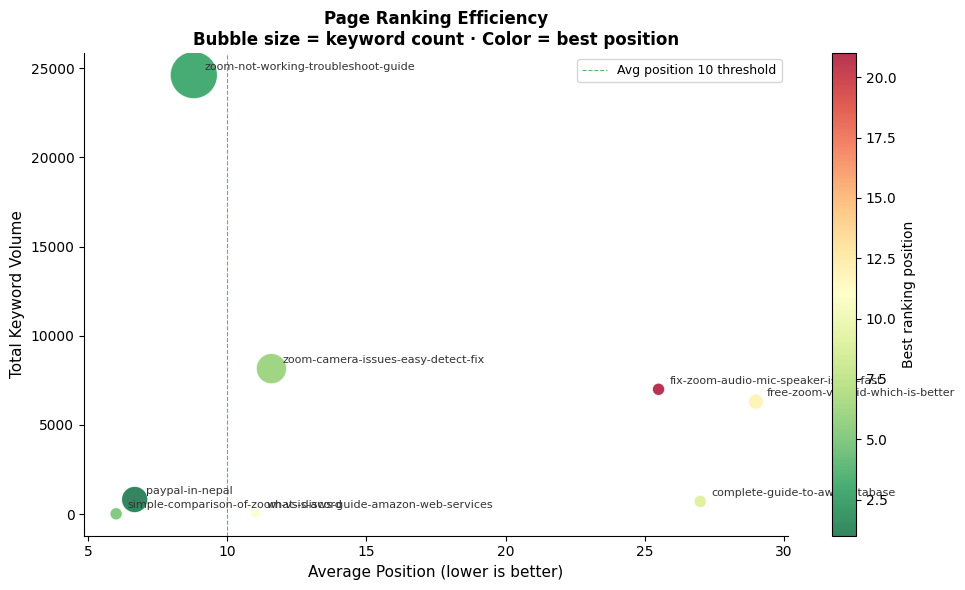

Chart saved.


In [18]:
# Clean page labels
page_positions['label'] = page_positions['Page'].str.replace(
    r'\[client-site\]/blogs/', '', regex=True
)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    page_positions['avg_position'],
    page_positions['total_volume'],
    s=page_positions['keyword_count'] * 40,
    c=page_positions['best_position'],
    cmap='RdYlGn_r',
    alpha=0.8,
    edgecolors='white',
    linewidth=0.8
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Best ranking position', fontsize=10)

for _, row in page_positions.iterrows():
    ax.annotate(
        row['label'],
        (row['avg_position'], row['total_volume']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8,
        color='#333333'
    )

ax.axvline(x=10, color='green', linestyle='--', linewidth=0.8, alpha=0.6, label='Avg position 10 threshold')

ax.set_xlabel('Average Position (lower is better)', fontsize=11)
ax.set_ylabel('Total Keyword Volume', fontsize=11)
ax.set_title(
    'Page Ranking Efficiency\nBubble size = keyword count · Color = best position',
    fontsize=12,
    fontweight='bold'
)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-ahrefs/chart/page_ranking_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")